## Import all necessary libraries ##

In [365]:
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)  
import seaborn as sns
import numpy as np
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from linearmodels import PooledOLS


## Read in dataset and modify it for regression analysis

I started by doing this analysis only for mucipipal waste.
I will later change it to other response variables, but to test out the diffent means this was a good first step.
I also dropped the policy variables and calculated a policy count instead as this lead to too much multicolliniarity issues.

In [366]:
df = pd.read_csv("./data/merged_dataset_all.csv")
policy_years_cols = ['WFD', 'WEEE_Directive_1', 'WEEE_Directive_2', 'WEEE_Directive_3', 'WEEE_Directive_4', 'RoHS_1', 'RoHS_2', 
                    'BL', 'EOLVD', 'LFD_1', 'LFD_2', 'SUP', 'CEAP_1', 'CEAP_2', 'CEAP_3', 'DRS', 'PT']
df["policy_count"] = (df[policy_years_cols] > 0).sum(axis=1)
df = df.drop(policy_years_cols, axis = 1)
df = df[df['country'] != "EU27_2020"]
df['joining_year'] = df['joining_year'].astype('int64')
df = df.drop(['packaging_recycling', 'electrical_recycling', 'battery_recycling', 'vehicle_recycling'],axis = 1)
df = df.dropna(subset=["municipal_recycling"])
df = df.sort_values(["country", "year"]).copy()

## Calculate correlation

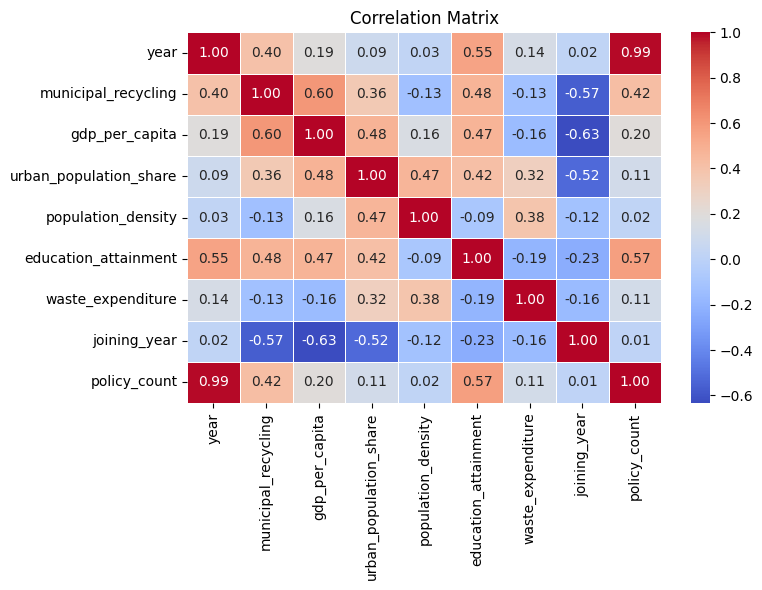

In [367]:
corr = df.drop('country', axis = 1).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


We can see that the year and poicy count is highly correlated which is not surprising. As more years pass, more policies are added. I will see hoch this affects the regressoin model and remove the year ant one try.

## Simple linear regression

All years until 2016, are training years and I will try to predict the recycling rate for the later years.
I do start with a simple linear regression and I will build on that later.

### Creation of the models ###

In [368]:
num_cols = [
    'gdp_per_capita',
    'urban_population_share',
    'population_density',
    'education_attainment',
    'waste_expenditure'
]

In [369]:
### With country and year ###
df_cy = df.copy()

## Imputate missing values in training set ##
# Interpolations if some variables are missing in the middle of the time series
df_cy[num_cols] = df_cy.groupby("country")[num_cols].transform(
    lambda x: x.interpolate(method="linear", limit_area="inside")
)
#Forward and backwardsfill, if we have some small gaps at the beginning and the end
df_cy[num_cols] = df_cy.groupby("country")[num_cols].ffill(limit=3)
df_cy[num_cols] = df_cy.groupby("country")[num_cols].bfill(limit=3)
#Imputatation of -1 for the rest
for col in ['gdp_per_capita', 'urban_population_share', 'population_density', 'education_attainment', 'waste_expenditure']: 
    df_cy[col + "_missing"] = df_cy[col].isna().astype(int)
    df_cy[col] = df_cy[col].fillna(-1)
df_cy

df_cy = pd.get_dummies(
    df_cy,
    columns=['country'],
    drop_first=True,
    dtype=int 
)

train_cy = df_cy[df_cy['year'] <= 2016].copy()
test_cy  = df_cy[df_cy['year'] > 2016].copy()

X_train_cy = train_cy.drop("municipal_recycling", axis = 1)
y_train_cy = train_cy['municipal_recycling']

X_train_cy = sm.add_constant(X_train_cy)
model_cy = sm.OLS(y_train_cy, X_train_cy)
results_cy = model_cy.fit()
print(results_cy.summary())



                             OLS Regression Results                            
Dep. Variable:     municipal_recycling   R-squared:                       0.932
Model:                             OLS   Adj. R-squared:                  0.926
Method:                  Least Squares   F-statistic:                     162.3
Date:                  Fr, 02 Jan 2026   Prob (F-statistic):          4.65e-218
Time:                         00:19:15   Log-Likelihood:                -1335.8
No. Observations:                  449   AIC:                             2744.
Df Residuals:                      413   BIC:                             2892.
Df Model:                           35                                         
Covariance Type:             nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
co

In [370]:
### Without country ###
df_y = df_cy.drop(
    columns=[c for c in df_cy.columns if c.startswith("country")]
)

train_y = df_y[df_y['year'] <= 2016].copy()
test_y  = df_y[df_y['year'] > 2016].copy()

import statsmodels.api as sm
X_train_y = train_y.drop("municipal_recycling", axis = 1)
y_train_y = train_y['municipal_recycling']

X_train_y = sm.add_constant(X_train_y)
model_y = sm.OLS(y_train_y, X_train_y)
results_y1 = model_y.fit()
print(results_y1.summary())

                             OLS Regression Results                            
Dep. Variable:     municipal_recycling   R-squared:                       0.623
Model:                             OLS   Adj. R-squared:                  0.615
Method:                  Least Squares   F-statistic:                     72.45
Date:                  Fr, 02 Jan 2026   Prob (F-statistic):           2.22e-86
Time:                         00:19:15   Log-Likelihood:                -1721.0
No. Observations:                  449   AIC:                             3464.
Df Residuals:                      438   BIC:                             3509.
Df Model:                           10                                         
Covariance Type:             nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
co

In [371]:
### Without country and year ###
train_nn = df_y[df_y['year'] <= 2016].copy()
test_nn  = df_y[df_y['year'] > 2016].copy()

train_nn = train_nn.drop('year', axis = 1)
test_nn = test_nn.drop('year', axis = 1)

import statsmodels.api as sm
X_train_nn = train_nn.drop("municipal_recycling", axis = 1)
y_train_nn = train_nn['municipal_recycling']

X_train_nn = sm.add_constant(X_train_nn)
model_nn = sm.OLS(y_train_nn, X_train_nn)
results_nn = model_nn.fit()
print(results_nn.summary())

                             OLS Regression Results                            
Dep. Variable:     municipal_recycling   R-squared:                       0.622
Model:                             OLS   Adj. R-squared:                  0.614
Method:                  Least Squares   F-statistic:                     80.17
Date:                  Fr, 02 Jan 2026   Prob (F-statistic):           5.72e-87
Time:                         00:19:15   Log-Likelihood:                -1721.9
No. Observations:                  449   AIC:                             3464.
Df Residuals:                      439   BIC:                             3505.
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
co

### Result comparison ###

In [372]:
def result_analysis(X_train, test_set, resonse_var, results): 
    # Split X_test and y_test

    for col in ['gdp_per_capita', 'urban_population_share', 'population_density', 'education_attainment', 'waste_expenditure']: 
        test_set[col + "_missing"] = test_set[col].isna().astype(int)
        test_set[col] = test_set[col].fillna(-1)

    X_test = test_set.drop(resonse_var, axis=1)
    y_test = test_set[resonse_var]

    # Add constant and make sure columns align (Important for one-hot-encoding)
    X_test = sm.add_constant(X_test)
    X_test = X_test.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    # Fill NA-values in test set --> I want to change that, there has to be a better way.
    #X_test = X_test.fillna(-1)  
    y_pred = results.predict(X_test)

    # Calculate rmse, mae and r2
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R²:   {r2:.3f}")
    metrics = pd.DataFrame({
        "RMSE": [rmse],
        "MAE": [mae],
        "R2": [r2]
    })
 
    # Plot predicted vs. true values and the residuals.
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # each plot will be 6x6 approx

    # ---- Plot 1: Observed vs Predicted ----
    axes[0].scatter(y_test, y_pred, alpha=0.6)
    axes[0].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linestyle="--"
    )
    axes[0].set_xlabel("Observed municipal recycling")
    axes[0].set_ylabel("Predicted municipal recycling")
    axes[0].set_title("Observed vs Predicted")

    # ---- Plot 2: Residuals vs Fitted ----
    residuals = y_test - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.6)
    axes[1].axhline(0, color="red", linestyle="--")
    axes[1].set_xlabel("Predicted values")
    axes[1].set_ylabel("Residuals")
    axes[1].set_title("Residuals vs Fitted")

    plt.tight_layout()
    plt.show()
    return metrics
    


RMSE: 4.96
MAE:  3.72
R²:   0.926


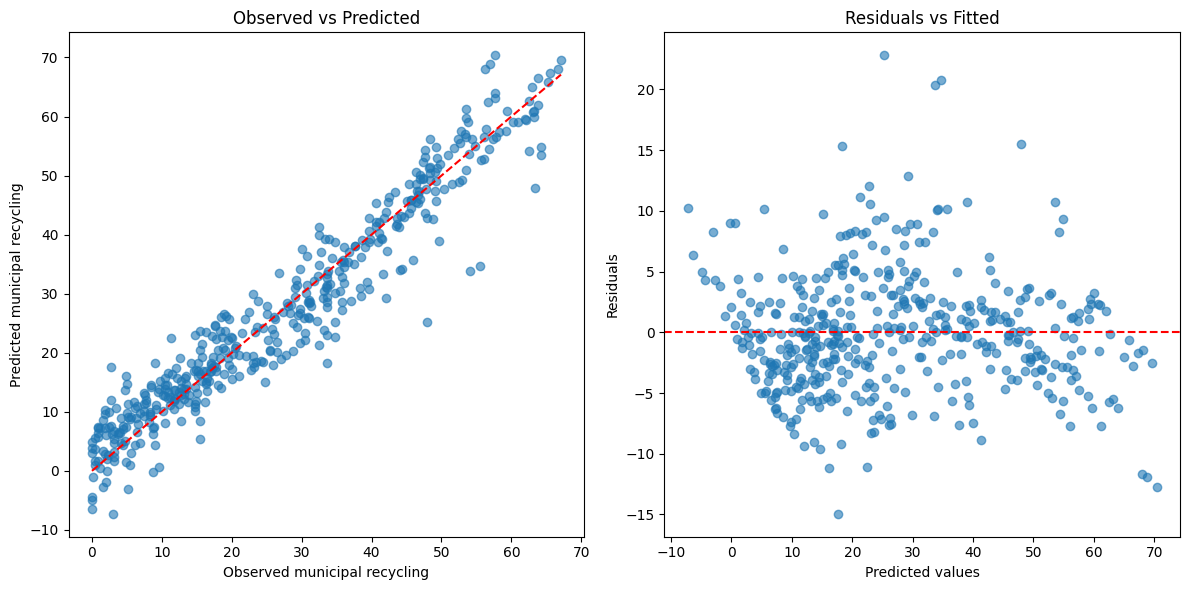

RMSE: 11.21
MAE:  9.48
R²:   0.440


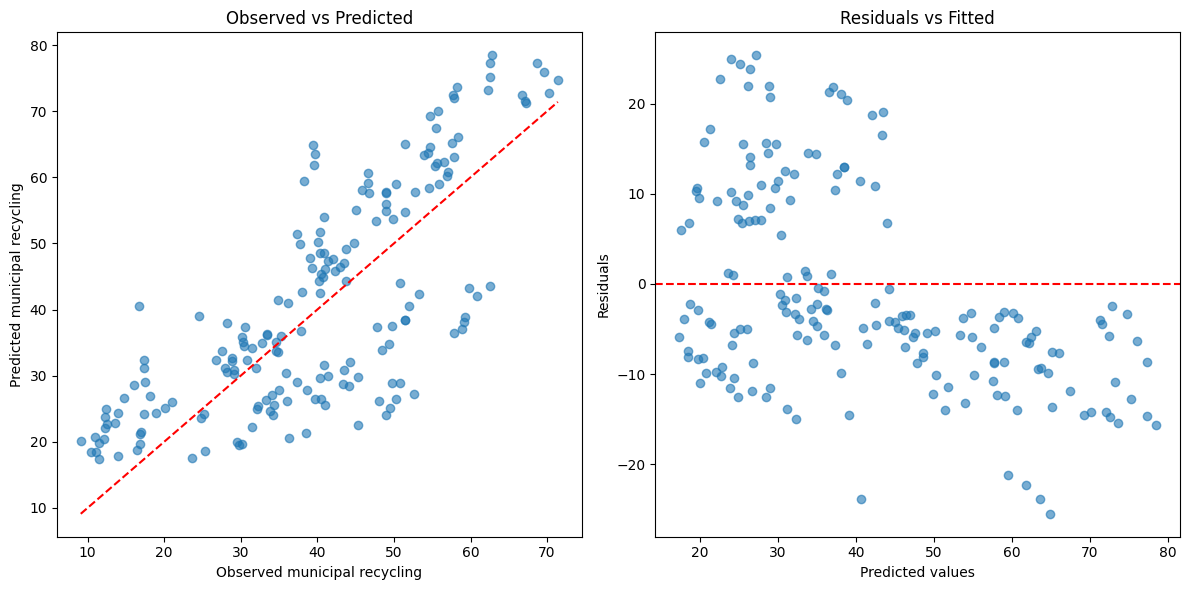

In [373]:
pred_cy = result_analysis(X_train = X_train_cy, test_set = train_cy, resonse_var="municipal_recycling", results = results_cy)
pred_cy = result_analysis(X_train = X_train_cy, test_set = test_cy, resonse_var="municipal_recycling", results = results_cy)

RMSE: 11.29
MAE:  8.52
R²:   0.616


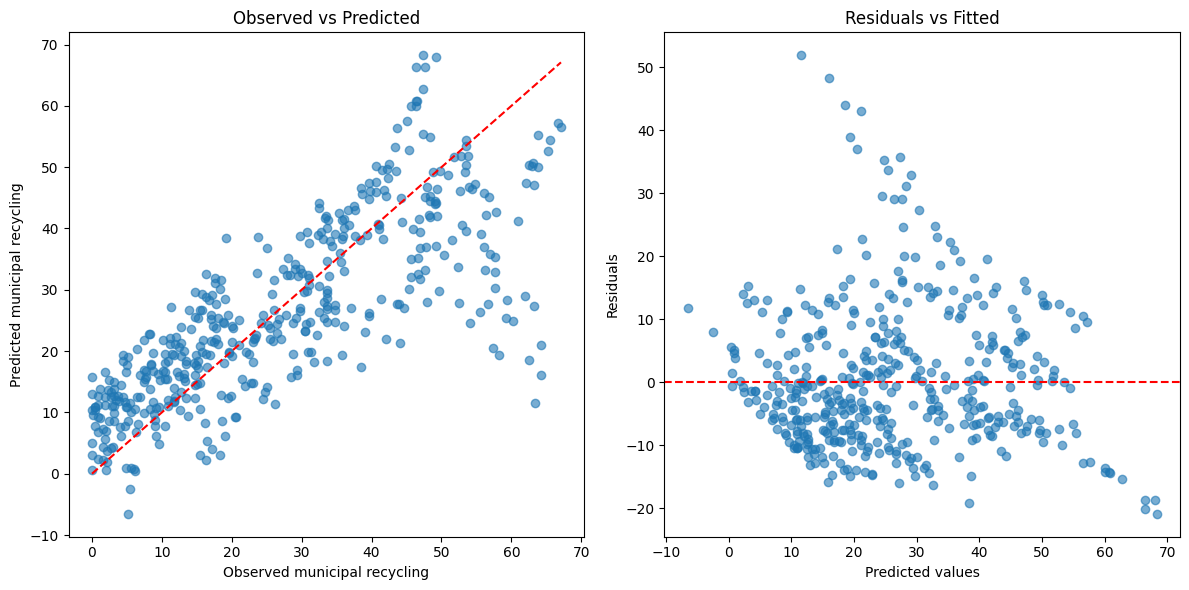

RMSE: 12.93
MAE:  10.69
R²:   0.254


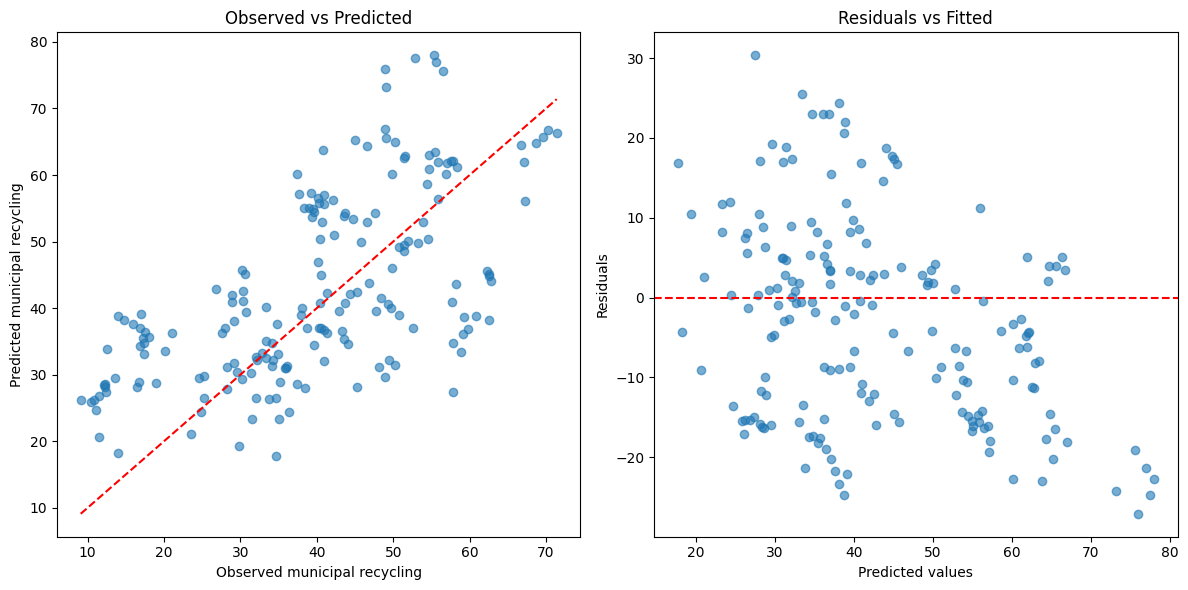

In [374]:
pred_y = result_analysis(X_train = X_train_y, test_set = train_y, resonse_var="municipal_recycling", results = results_y)
pred_cy = result_analysis(X_train = X_train_y, test_set = test_y, resonse_var="municipal_recycling", results = results_y)

RMSE: 11.33
MAE:  8.49
R²:   0.613


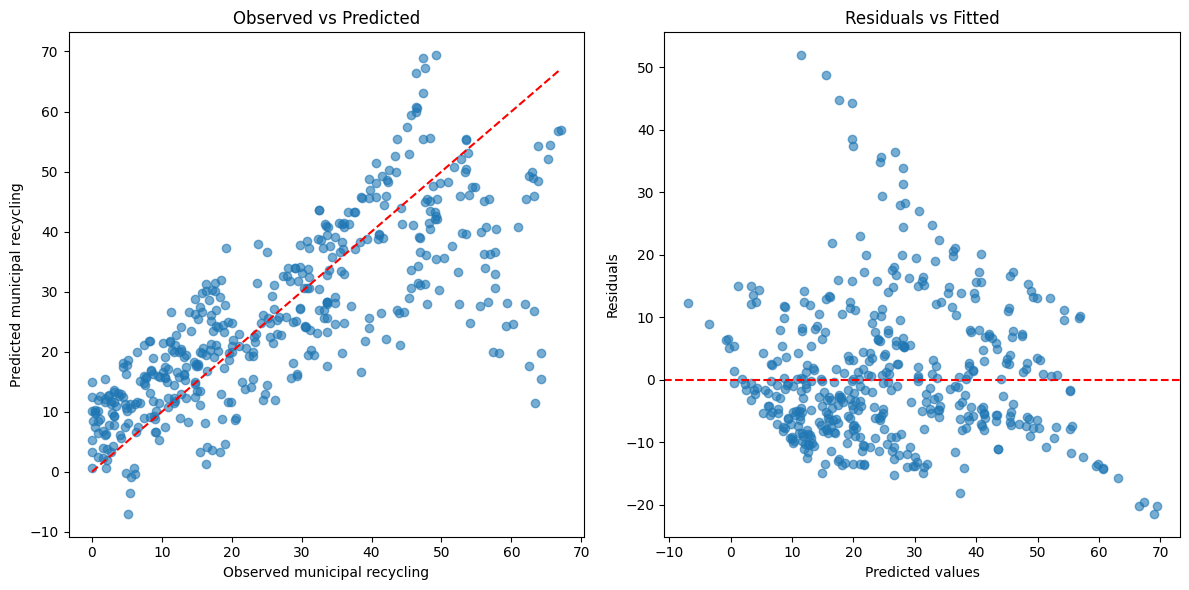

RMSE: 13.09
MAE:  10.82
R²:   0.236


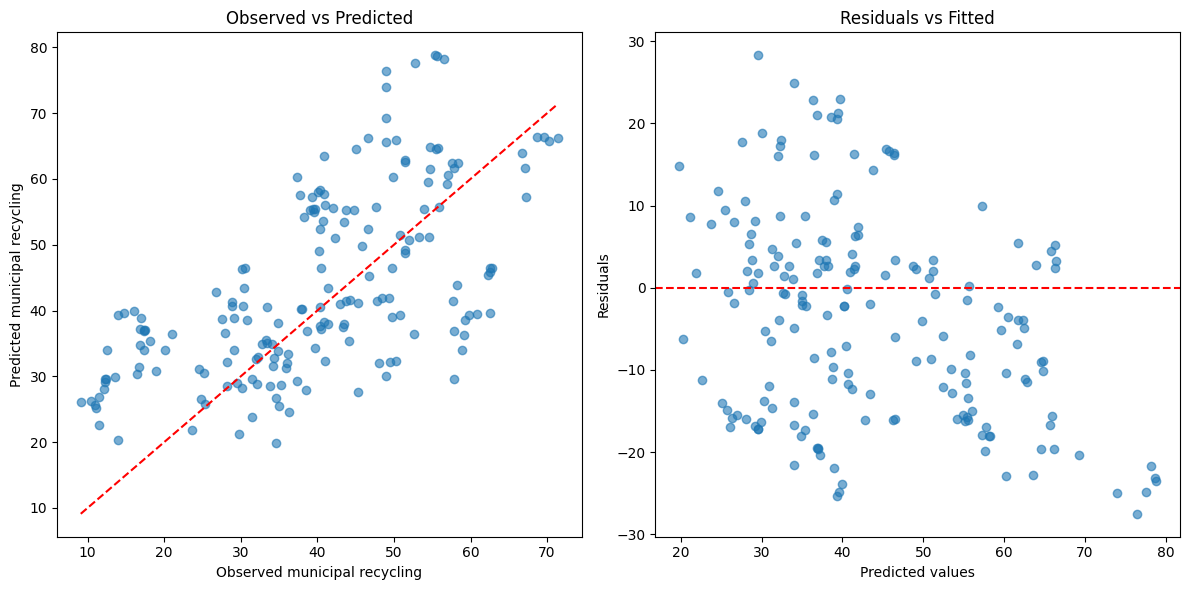

In [375]:
pred_y = result_analysis(X_train = X_train_nn, test_set = train_nn, resonse_var="municipal_recycling", results = results_nn)
pred_cy = result_analysis(X_train = X_train_nn, test_set = test_nn, resonse_var="municipal_recycling", results = results_nn)

## Panel regression ##

In [376]:
df_cy = df.copy()

## Imputate missing values in training set ##
# Interpolations if some variables are missing in the middle of the time series
df_cy[num_cols] = df_cy.groupby("country")[num_cols].transform(
    lambda x: x.interpolate(method="linear", limit_area="inside")
)
#Forward and backwardsfill, if we have some small gaps at the beginning and the end
df_cy[num_cols] = df_cy.groupby("country")[num_cols].ffill(limit=3)
df_cy[num_cols] = df_cy.groupby("country")[num_cols].bfill(limit=3)
#Imputatation of -1 for the rest
for col in ['gdp_per_capita', 'urban_population_share', 'population_density', 'education_attainment', 'waste_expenditure']: 
    df_cy[col + "_missing"] = df_cy[col].isna().astype(int)
    df_cy[col] = df_cy[col].fillna(-1)
df_cy
df_cy = df_cy.set_index(['country', 'year']).sort_index()

train_cy = df_cy[df_cy.index.get_level_values('year') <= 2016].copy()
test_cy  = df_cy[df_cy.index.get_level_values('year') > 2016].copy()


X_train_cy = train_cy.drop("municipal_recycling", axis = 1)
y_train_cy = train_cy['municipal_recycling']

exog = sm.tools.tools.add_constant(X_train_cy)
endog = y_train_cy
mod = PooledOLS(endog, exog, check_rank=False)
pooledOLS_res = mod.fit()
# Store values for checking homoskedasticity graphically
#fittedvals_pooled_OLS = pooledOLS_res.predict().fitted_values
#residuals_pooled_OLS = pooledOLS_res.resids

In [377]:
def panel_prediction_analysis(
    results,
    train_df,
    test_df,
    target,
    add_constant=True
):

    X_train = train_df.drop(columns=target)
    y_train = train_df[target]

    if add_constant:
        X_train = sm.add_constant(X_train, has_constant="add")

    y_train_pred = results.predict(X_train)

    # --------------------
    # Prepare TEST data
    # --------------------
    X_test = test_df.drop(columns=target)
    y_test = test_df[target]

    if add_constant:
        X_test = sm.add_constant(X_test, has_constant="add")

    # Ensure column alignment
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_test_pred = results.predict(X_test)

    # --------------------
    # Metrics
    # --------------------
    metrics = {
        "Train": {
            "RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
            "MAE": mean_absolute_error(y_train, y_train_pred),
            "R2": r2_score(y_train, y_train_pred),
        },
        "Test": {
            "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
            "MAE": mean_absolute_error(y_test, y_test_pred),
            "R2": r2_score(y_test, y_test_pred),
        },
    }
    print(metrics)

    # --------------------
    # Plotting
    # --------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    # Train plot
    axes[0].scatter(y_train, y_train_pred, alpha=0.6)
    axes[0].plot(
        [y_train.min(), y_train.max()],
        [y_train.min(), y_train.max()],
        linestyle="--"
    )
    axes[0].set_title("Train: Observed vs Predicted")
    axes[0].set_xlabel("Observed")
    axes[0].set_ylabel("Predicted")

    # Test plot
    axes[1].scatter(y_test, y_test_pred, alpha=0.6)
    axes[1].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )
    axes[1].set_title("Test: Observed vs Predicted")
    axes[1].set_xlabel("Observed")

    plt.tight_layout()
    plt.show()

    return metrics


{'Train': {'RMSE': np.float64(11.200300989784807), 'MAE': 8.614419676321969, 'R2': 0.6217184106925222}, 'Test': {'RMSE': np.float64(13.086437799020729), 'MAE': 10.820644003110848, 'R2': 0.2357264905395856}}


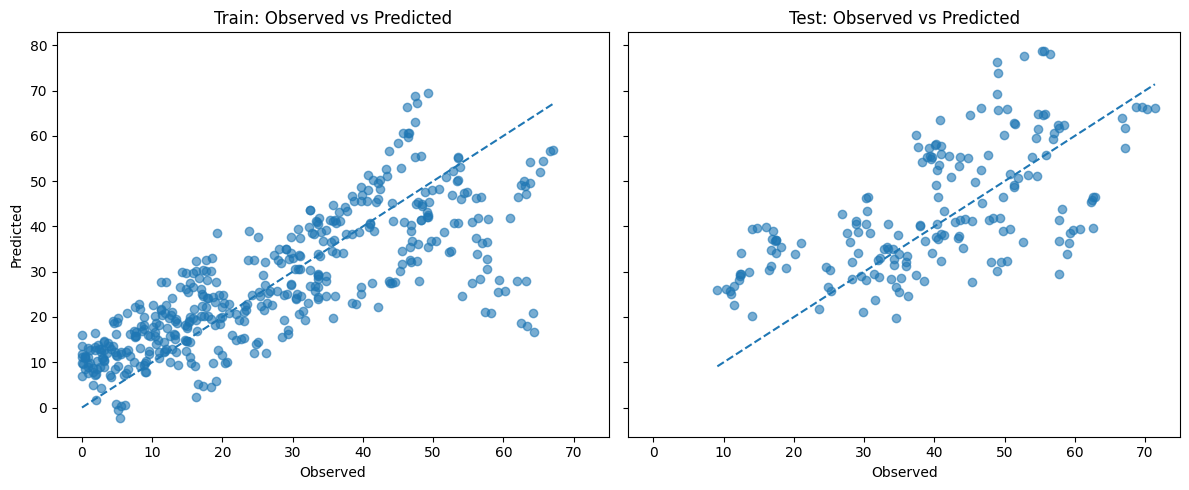

{'Train': {'RMSE': np.float64(11.200300989784807), 'MAE': 8.614419676321969, 'R2': 0.6217184106925222}, 'Test': {'RMSE': np.float64(13.086437799020729), 'MAE': 10.820644003110848, 'R2': 0.2357264905395856}}


In [378]:
metrics = panel_prediction_analysis(
    results=pooledOLS_res,
    train_df=train_cy,
    test_df=test_cy,
    target="municipal_recycling",
    add_constant=True
)

print(metrics)


In [379]:
from linearmodels.panel import PanelOLS

df_cy = df.copy()

## Imputate missing values in training set ##
# Interpolations if some variables are missing in the middle of the time series
df_cy[num_cols] = df_cy.groupby("country")[num_cols].transform(
    lambda x: x.interpolate(method="linear", limit_area="inside")
)
#Forward and backwardsfill, if we have some small gaps at the beginning and the end
df_cy[num_cols] = df_cy.groupby("country")[num_cols].ffill(limit=3)
df_cy[num_cols] = df_cy.groupby("country")[num_cols].bfill(limit=3)
#Imputatation of -1 for the rest
for col in ['gdp_per_capita', 'urban_population_share', 'population_density', 'education_attainment', 'waste_expenditure']: 
    df_cy[col + "_missing"] = df_cy[col].isna().astype(int)
    df_cy[col] = df_cy[col].fillna(-1)
df_cy
df_cy = df_cy.set_index(['country', 'year']).sort_index()

train_cy = df_cy[df_cy.index.get_level_values('year') <= 2016].copy()
test_cy  = df_cy[df_cy.index.get_level_values('year') > 2016].copy()


X_train_cy = train_cy.drop("municipal_recycling", axis = 1)
y_train_cy = train_cy['municipal_recycling']

#X_train_cy = sm.add_constant(X_train_cy)

# Fixed effects model
model = PanelOLS(y_train_cy, X_train_cy, entity_effects=True, time_effects=True, check_rank=False, drop_absorbed=True)
results = model.fit()
print(results.summary)


                           PanelOLS Estimation Summary                           
Dep. Variable:     municipal_recycling   R-squared:                        0.0780
Estimator:                    PanelOLS   R-squared (Between):              0.7388
No. Observations:                  449   R-squared (Within):               0.1441
Date:                  Fr, Jan 02 2026   R-squared (Overall):              0.7152
Time:                         00:19:19   Log-likelihood                   -1329.6
Cov. Estimator:             Unadjusted                                           
                                         F-statistic:                      4.8192
Entities:                           27   P-value                           0.0000
Avg Obs:                        16.630   Distribution:                   F(7,399)
Min Obs:                       10.0000                                           
Max Obs:                        17.000   F-statistic (robust):             4.8192
                

C:\Users\ameli\AppData\Local\Temp\ipykernel_6272\1775855816.py:31: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

joining_year, gdp_per_capita_missing, urban_population_share_missing, education_attainment_missing, waste_expenditure_missing

  results = model.fit()


In [380]:
def panel_fe_prediction_analysis(
    results,
    train_df,
    test_df,
    target
):
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    used_cols = results.model.exog.vars

    # TRAIN
    X_train = train_df[used_cols]
    y_train = train_df[target]
    y_train_pred = results.predict(X_train)

    # TEST
    X_test = test_df[used_cols]
    y_test = test_df[target]
    y_test_pred = results.predict(X_test)

    metrics = {
        "Train": {
            "RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
            "MAE": mean_absolute_error(y_train, y_train_pred),
            "R2": r2_score(y_train, y_train_pred),
        },
        "Test": {
            "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
            "MAE": mean_absolute_error(y_test, y_test_pred),
            "R2": r2_score(y_test, y_test_pred),
        },
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    axes[0].scatter(y_train, y_train_pred, alpha=0.6)
    axes[0].plot(
        [y_train.min(), y_train.max()],
        [y_train.min(), y_train.max()],
        linestyle="--"
    )
    axes[0].set_title("Train: Observed vs Predicted")
    axes[0].set_xlabel("Observed")
    axes[0].set_ylabel("Predicted")

    axes[1].scatter(y_test, y_test_pred, alpha=0.6)
    axes[1].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )
    axes[1].set_title("Test: Observed vs Predicted")
    axes[1].set_xlabel("Observed")

    plt.tight_layout()
    plt.show()

    return metrics


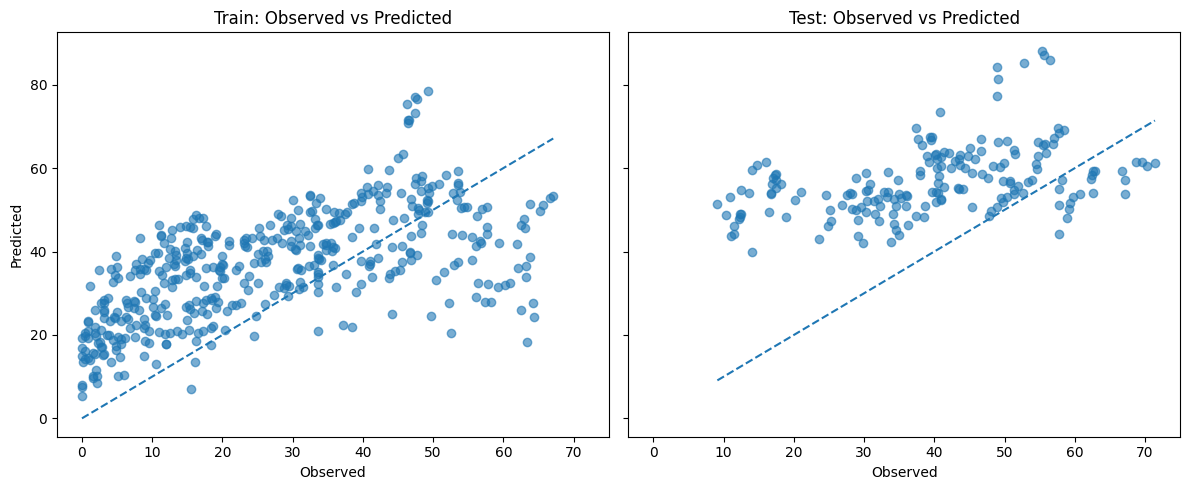

{'Train': {'RMSE': np.float64(17.274077433310328), 'MAE': 14.806525323593311, 'R2': 0.10020092672298986}, 'Test': {'RMSE': np.float64(22.0465924969428), 'MAE': 18.97421542053289, 'R2': -1.1691464069123878}}


In [381]:
metrics = panel_fe_prediction_analysis(
    results=results,
    train_df=train_cy,
    test_df=test_cy,
    target="municipal_recycling"
)

print(metrics)
